Выполнил: __Кондрат Никита Игоревич__, группа: __P3123__

# Очистка и трансформация данных

## Цель работы
Освоение методов очистки и трансформации данных с использованием библиотеки pandas на примере реальных данных из Kaggle.

## Теоретические сведения
####Основные понятия:

- Предобработка данных — подготовка данных к анализу
- Очистка данных — устранение ошибок и пропусков
- Трансформация данных — преобразование данных для анализа
- Pandas — библиотека для работы с данными в Python

##Используемый набор данных
Dataset: Titanic (https://www.kaggle.com/c/titanic/data)
#### Структура данных:
- PassengerId — идентификатор пассажира
- Survived — выжил ли пассажир (0 = нет; 1 = да)
- Pclass — класс билета
- Name — имя
- Sex — пол
- Age — возраст
- SibSp — количество братьев/сестер/супругов на борту
- Parch — количество родителей/детей на борту
- Ticket — номер билета
- Fare — стоимость билета
- Cabin — номер каюты
- Embarked — порт посадки

# Задания

- Импорты

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 1. Первичный анализ данных

- Загрузить данные из CSV-файла

In [ ]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

titanic_df = pd.read_csv(url)

- Вывести первые 10 строк дата-фрейма

In [ ]:
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


- Проверить типы данных каждого столбца

In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Определить количество пропусков в каждом столбце

In [ ]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


- Получить статистические характеристики числовых признаков

In [ ]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- count - количество непустых значений
- mean - среднее значение
- std - стандартное отклонение (разброс данных)
- min - минимальное значение
- 25% - первый квартиль (25% данных ниже этого значения)
- 50% - медиана (среднее значение выборки)
- 75% - третий квартиль (75% данных ниже этого значения)
- max - максимальное значение

- Построить гистограммы распределения для числовых признаков

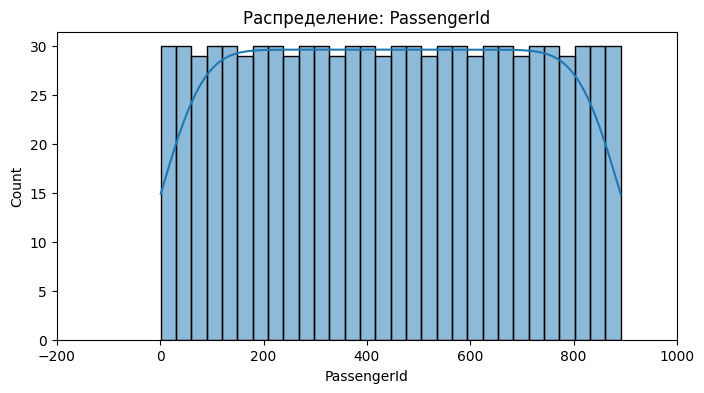

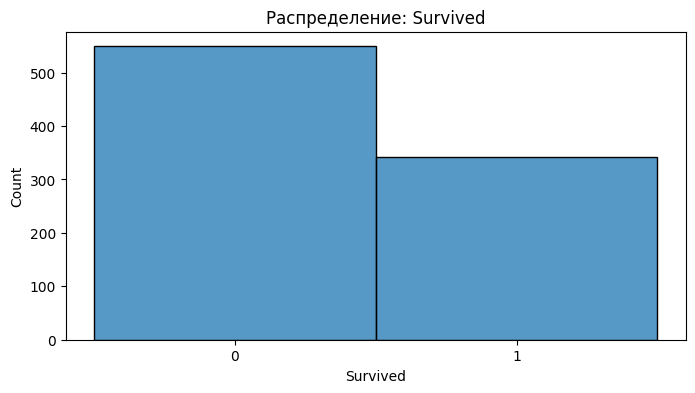

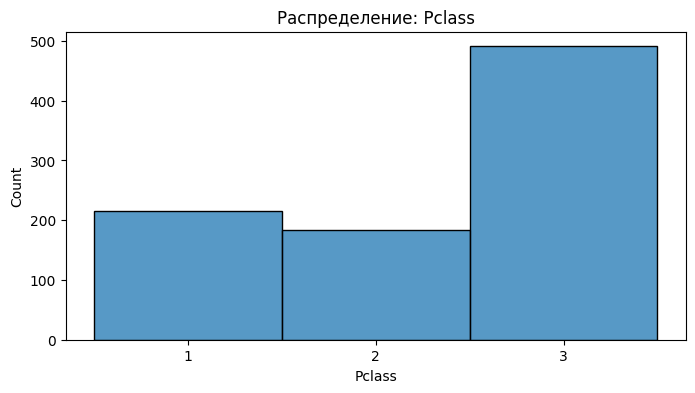

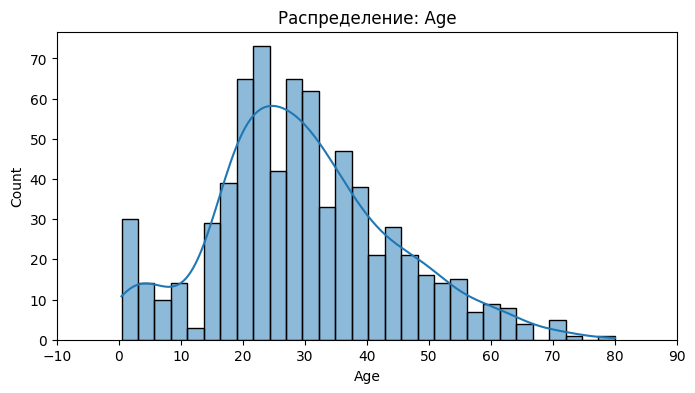

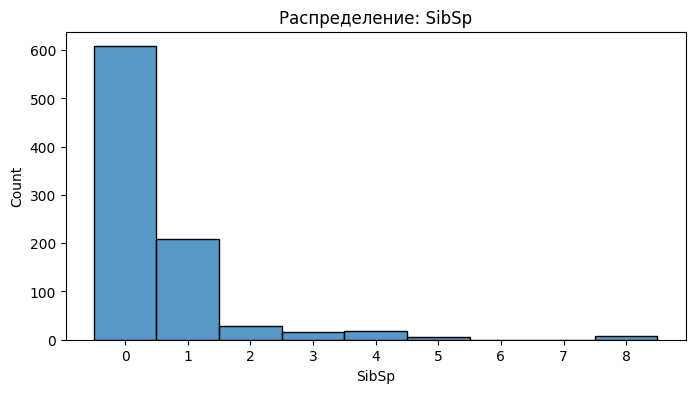

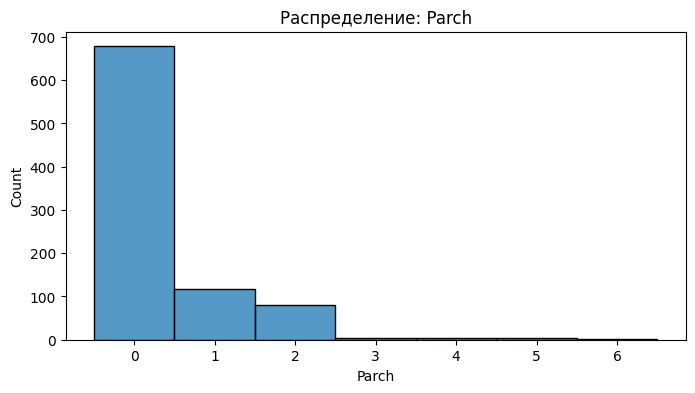

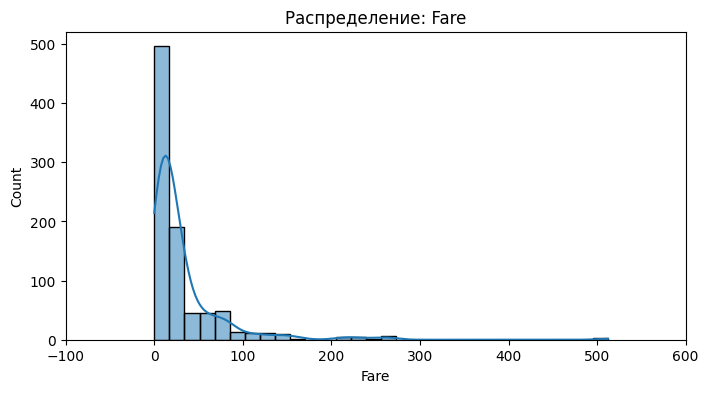

In [ ]:
numeric_cols = titanic_df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    if col in ['Survived', 'SibSp', 'Parch', 'Pclass']:
        sns.histplot(titanic_df[col], kde=False, discrete=True)
        plt.xticks(range(int(titanic_df[col].min()), int(titanic_df[col].max()) + 1))
    else:
        sns.histplot(titanic_df[col], kde=True, bins=30)
        ticks = plt.xticks()[0]
        plt.xticks([int(x) for x in ticks])

    plt.title(f'Распределение: {col}')
    plt.show()

## 2. Обработка пропусков

- Определить столбцы с пропусками

In [ ]:
missing = titanic_df.isnull().sum()

missing[missing > 0]

,0
Age,177
Cabin,687
Embarked,2


Для столбца Age:
- Посчитать среднее и медианное значение
- Заполнить пропуски медианным значением
- Создать новый признак Age_group на основе заполненного возраста

In [ ]:
age_mean = titanic_df['Age'].mean()
print(f"Средний возраст: {age_mean:.2f}")

age_median = titanic_df['Age'].median()
print(f"Медианный возраст: {age_median:.2f}")

Средний возраст: 29.70
Медианный возраст: 28.00


In [ ]:
# Заполняем пропуски в столбце Age медианой
titanic_df['Age'] = titanic_df['Age'].fillna(age_median)

print(f"Осталось пропусков в Age: {titanic_df['Age'].isnull().sum()}")

Осталось пропусков в Age: 0


In [ ]:
def categorize_age(age):
    if age < 18:
        return 'Child'
    elif age < 35:
        return 'Young'
    elif age < 60:
        return 'Adult'
    else:
        return 'Elderly'

titanic_df['Age_group'] = titanic_df['Age'].apply(categorize_age)

In [ ]:
print(titanic_df['Age_group'].value_counts(), "\n")

titanic_df[['Age', 'Age_group']].head(10)

Age_group
Young      543
Adult      209
Child      113
Elderly     26
Name: count, dtype: int64 



,Age,Age_group
0,22.0,Young
1,38.0,Adult
2,26.0,Young
3,35.0,Adult
4,35.0,Adult
5,28.0,Young
6,54.0,Adult
7,2.0,Child
8,27.0,Young
9,14.0,Child


Для столбца Embarked:
- Определить наиболее часто встречающееся значение
- Заполнить пропуски модой


In [ ]:
mode_value = titanic_df['Embarked'].mode()[0]
print(f"Наиболее частое значение: {mode_value}")

Наиболее частое значение: S


In [ ]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(mode_value)

print(f"Осталось пропусков в Embarked: {titanic_df['Embarked'].isnull().sum()}")

Осталось пропусков в Embarked: 0


Для столбца Cabin:
- Рассмотреть возможность удаления или создания нового признака на основе первой буквы

In [ ]:
print("\nРаспределение по палубам:")
print(titanic_df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown').value_counts())


Распределение по палубам:
Cabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


In [ ]:
titanic_df['Cabin_Deck'] = titanic_df['Cabin'].str[0]

titanic_df['Cabin_Deck'].fillna('Unknown', inplace=True)

titanic_df.drop(columns=['Cabin'], inplace=True)

/tmp/ipykernel_3247/1206853497.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Cabin_Deck'].fillna('Unknown', inplace=True)


## 3. Работа с типами данных

- Преобразовать Pclass в категориальный тип строкового значения (из числового - в строковое: 1 - F, 2 - S, 3 - T )

In [ ]:
pclass_mapping = {
    1: 'F',
    2: 'S',
    3: 'T'
}

titanic_df['Pclass'] = titanic_df['Pclass'].replace(pclass_mapping)

print(titanic_df['Pclass'].value_counts())
print(titanic_df['Pclass'].dtype)

Pclass
T    491
F    216
S    184
Name: count, dtype: int64
object


In [ ]:
titanic_df[['Pclass', 'Survived']].head()

,Pclass,Survived
0,T,0
1,F,1
2,T,1
3,F,1
4,T,0


- Создать новый признак Title из столбца Name (мистер, миссис и т.д.)

In [ ]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = titanic_df['Title'].value_counts()[titanic_df['Title'].value_counts() < 2].index
titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Other')

print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Other       8
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Name: count, dtype: int64


- Преобразовать Sex в числовой формат (0/1)

In [ ]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 1, 'female': 0})

print(titanic_df['Sex'].value_counts())

Sex
1    577
0    314
Name: count, dtype: int64


- Создать признак FamilySize = SibSp + Parch + 1

In [ ]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

print(titanic_df[['SibSp', 'Parch', 'FamilySize']].head(10))
print(f"\nДиапазон FamilySize: от {titanic_df['FamilySize'].min()} до {titanic_df['FamilySize'].max()}")

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2

Диапазон FamilySize: от 1 до 11


- Создать признак IsAlone (1 если FamilySize = 1, иначе 0)

In [ ]:
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

print(titanic_df['IsAlone'].value_counts())

IsAlone
1    537
0    354
Name: count, dtype: int64


In [ ]:
titanic_df = titanic_df.drop(columns=['SibSp', 'Parch']) #удалил чтобы не было загромождения классов

In [ ]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Age_group,Cabin_Deck,Title,FamilySize,IsAlone
0,1,0,T,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,7.2500,S,Young,Unknown,Mr,2,0
1,2,1,F,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,71.2833,C,Adult,C,Mrs,2,0
2,3,1,T,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,7.9250,S,Young,Unknown,Miss,1,1
3,4,1,F,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,53.1000,S,Adult,C,Mrs,2,0
4,5,0,T,"Allen, Mr. William Henry",1,35.0,373450,8.0500,S,Adult,Unknown,Mr,1,1


## 4. Удаление выбросов

- Построить boxplot для признака Fare

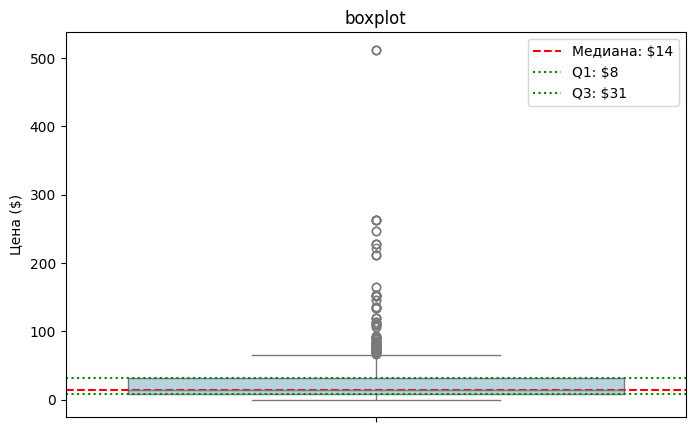

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=titanic_df, y='Fare', color='lightblue')

Q1 = titanic_df['Fare'].quantile(0.25)
Q3 = titanic_df['Fare'].quantile(0.75)
median = titanic_df['Fare'].median()

plt.axhline(median, color='red', linestyle='--', label=f'Медиана: ${median:.0f}')
plt.axhline(Q1, color='green', linestyle=':', label=f'Q1: ${Q1:.0f}')
plt.axhline(Q3, color='green', linestyle=':', label=f'Q3: ${Q3:.0f}')

plt.title('boxplot')
plt.ylabel('Цена ($)')
plt.legend()
plt.show()

- Определить выбросы с помощью IQR-метода

In [ ]:
Q1 = titanic_df['Fare'].quantile(0.25)
Q3 = titanic_df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print(f"   Q1 (25%): ${Q1:.2f}")
print(f"   Q3 (75%): ${Q3:.2f}")
print(f"   IQR: ${IQR:.2f}")
print(f"\nГраницы нормальных значений:")
print(f"   Нижняя: ${lower_bound:.2f}")
print(f"   Верхняя: ${upper_bound:.2f}")

   Q1 (25%): $7.91
   Q3 (75%): $31.00
   IQR: $23.09

Границы нормальных значений:
   Нижняя: $0.00
   Верхняя: $65.63


In [ ]:
outliers = titanic_df[(titanic_df['Fare'] < lower_bound) | (titanic_df['Fare'] > upper_bound)]

print(f"\nКоличество выбросов: {len(outliers)} ({len(outliers)/len(titanic_df)*100:.1f}%)")
print(f"Диапазон выбросов: ${outliers['Fare'].min():.2f} — ${outliers['Fare'].max():.2f}")
print(f"\nТоп-5 самых дорогих билетов (выбросы):")
print(outliers[['Fare', 'Pclass', 'Survived']].sort_values('Fare', ascending=False).head())


Количество выбросов: 116 (13.0%)
Диапазон выбросов: $66.60 — $512.33

Топ-5 самых дорогих билетов (выбросы):
         Fare Pclass  Survived
258  512.3292      F         1
737  512.3292      F         1
679  512.3292      F         1
27   263.0000      F         0
341  263.0000      F         1


- Визуализировать распределение Age

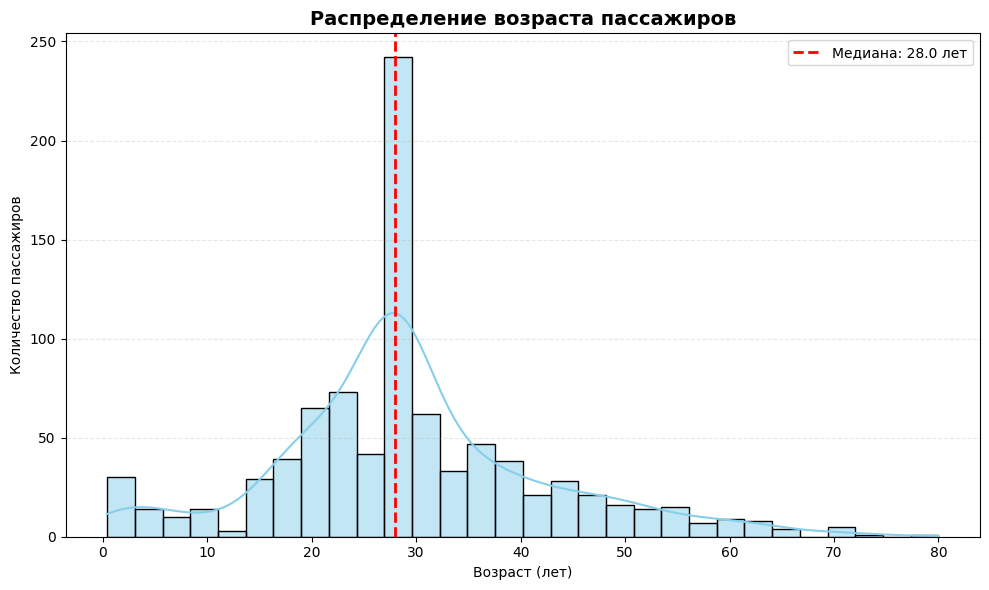

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic_df, x='Age', kde=True, bins=30, color='skyblue', edgecolor='black')

median_age = titanic_df['Age'].median()
plt.axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Медиана: {median_age:.1f} лет')

plt.title('Распределение возраста пассажиров', fontsize=14, fontweight='bold')
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

- Применить winsorization для признака Fare

In [ ]:
print(f"Границы по IQR-методу:")
print(f"Нижний порог: ${lower_bound:.2f}")
print(f"Верхний порог: ${upper_bound:.2f}")

titanic_df['Fare'] = titanic_df['Fare'].clip(
    lower=lower_bound,
    upper=upper_bound
)
titanic_df.head(10)

Границы по IQR-методу:
Нижний порог: $0.00
Верхний порог: $65.63


,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Age_group,Cabin_Deck,Title,FamilySize,IsAlone
0,1,0,T,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,7.2500,S,Young,Unknown,Mr,2,0
1,2,1,F,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,65.6344,C,Adult,C,Mrs,2,0
2,3,1,T,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,7.9250,S,Young,Unknown,Miss,1,1
3,4,1,F,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,53.1000,S,Adult,C,Mrs,2,0
4,5,0,T,"Allen, Mr. William Henry",1,35.0,373450,8.0500,S,Adult,Unknown,Mr,1,1
5,6,0,T,"Moran, Mr. James",1,28.0,330877,8.4583,Q,Young,Unknown,Mr,1,1
6,7,0,F,"McCarthy, Mr. Timothy J",1,54.0,17463,51.8625,S,Adult,E,Mr,1,1
7,8,0,T,"Palsson, Master. Gosta Leonard",1,2.0,349909,21.0750,S,Child,Unknown,Master,5,0
8,9,1,T,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,347742,11.1333,S,Young,Unknown,Mrs,3,0
9,10,1,S,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,237736,30.0708,C,Child,Unknown,Mrs,2,0


- Заменить экстремальные значения на 95-й перцентиль (для Age)

In [ ]:
percentile_95 = titanic_df['Age'].quantile(0.95)

print(f"95-й перцентиль возраста: {percentile_95:.2f} лет")
print(f"Максимальный возраст до обработки: {titanic_df['Age'].max():.1f} лет")

95-й перцентиль возраста: 54.00 лет
Максимальный возраст до обработки: 80.0 лет


In [ ]:
titanic_df['Age'] = titanic_df['Age'].clip(upper=percentile_95)

print(f"   Максимальный возраст: {titanic_df['Age'].max():.1f} лет")

   Максимальный возраст: 54.0 лет


## 5. Агрегация данных

- Посчитать среднее выживание по классам

In [ ]:
survival_by_class = titanic_df.groupby('Pclass')['Survived'].mean()

survival_by_class

,Survived
Pclass,
F,0.629630
S,0.472826
T,0.242363


- Группировать данные по Pclass и Sex

In [ ]:
pd.crosstab(titanic_df['Pclass'], titanic_df['Sex'])

Sex,0,1
Pclass,,
F,94,122
S,76,108
T,144,347


- Посчитать медианный возраст по портам посадки

In [ ]:
# Группируем по порту и считаем медиану возраста
median_age_by_port = titanic_df.groupby('Embarked')['Age'].median()

median_age_by_port

,Age
Embarked,
C,28.0
Q,28.0
S,28.0


- Создать сводную таблицу выживаемости по новым признакам

In [ ]:
print("Выживаемость по возрастным группам:")
age_group_survival = titanic_df.groupby('Age_group')['Survived'].agg(['count', 'mean'])
age_group_survival['survival_%'] = (age_group_survival['mean'] * 100).round(1)
print(age_group_survival[['count', 'survival_%']])

print("\nВыживаемость по титулам:")
title_survival = titanic_df.groupby('Title')['Survived'].agg(['count', 'mean'])
title_survival['survival_%'] = (title_survival['mean'] * 100).round(1)
print(title_survival[['count', 'survival_%']])

print("\nВыживаемость по статусу 'один/с семьёй':")
alone_survival = titanic_df.groupby('IsAlone')['Survived'].agg(['count', 'mean'])
alone_survival['survival_%'] = (alone_survival['mean'] * 100).round(1)
alone_survival.index = alone_survival.index.map({0: 'С семьёй', 1: 'Один'})
print(alone_survival[['count', 'survival_%']])

Выживаемость по возрастным группам:
           count  survival_%
Age_group                   
Adult        209        41.6
Child        113        54.0
Elderly       26        26.9
Young        543        34.4

Выживаемость по титулам:
        count  survival_%
Title                    
Col         2        50.0
Dr          7        42.9
Major       2        50.0
Master     40        57.5
Miss      182        69.8
Mlle        2       100.0
Mr        517        15.7
Mrs       125        79.2
Other       8        62.5
Rev         6         0.0

Выживаемость по статусу 'один/с семьёй':
          count  survival_%
IsAlone                    
С семьёй    354        50.6
Один        537        30.4


- Сохранить очищенные данные в новый CSV-файл

In [ ]:
titanic_df.to_csv('titanic_clean.csv', index=False)

## 6. Вычислить метрики качества очистки данных

- Процент заполненных пропусков

In [ ]:
def calculate_missing_metrics(original_df, cleaned_df):
    print("=" * 70)
    print("МЕТРИКА 1: ПРОЦЕНТ ЗАПОЛНЕННЫХ ПРОПУСКОВ")
    print("=" * 70)

    missing_before = original_df.isnull().sum()

    missing_after = cleaned_df.isnull().sum()

    filled = missing_before - missing_after

    total_rows = len(cleaned_df)
    fill_percentage = (filled / total_rows * 100).round(2)

    metrics_df = pd.DataFrame({
        'Пропусков_до': missing_before,
        'Пропусков_после': missing_after,
        'Заполнено': filled,
        'Процент_заполнения': fill_percentage
    })

    metrics_df = metrics_df[metrics_df['Пропусков_до'] > 0]

    print(metrics_df)
    print(f"\nВсего заполнено пропусков: {filled.sum()} из {total_rows} строк")
    print(f"Процент заполненных данных: {fill_percentage.sum():.2f}%")

    return metrics_df

missing_metrics = calculate_missing_metrics(pd.read_csv(url), titanic_df)

МЕТРИКА 1: ПРОЦЕНТ ЗАПОЛНЕННЫХ ПРОПУСКОВ
          Пропусков_до  Пропусков_после  Заполнено  Процент_заполнения
Age              177.0              0.0      177.0               19.87
Cabin            687.0              NaN        NaN                 NaN
Embarked           2.0              0.0        2.0                0.22

Всего заполнено пропусков: 179.0 из 891 строк
Процент заполненных данных: 20.09%


- Количество уникальных значений в категориальных признаках

In [ ]:
def analyze_categorical_features(df):
    print("\n" + "=" * 70)
    print("МЕТРИКА 2: УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КАТЕГОРИАЛЬНЫХ ПРИЗНАКАХ")
    print("=" * 70)

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    binary_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
                   if df[col].nunique() <= 2]
    categorical_cols.extend(binary_cols)

    stats = []
    for col in categorical_cols:
        unique_count = df[col].nunique()
        unique_values = df[col].unique()[:10]
        value_counts = df[col].value_counts()

        stats.append({
            'Столбец': col,
            'Уникальных_значений': unique_count,
            'Тип_данных': str(df[col].dtype),
            'Примеры_значений': ', '.join(map(str, unique_values)),
            'Наиболее_частое': value_counts.index[0] if len(value_counts) > 0 else 'N/A',
            'Частота': value_counts.iloc[0] if len(value_counts) > 0 else 0
        })

    stats_df = pd.DataFrame(stats)
    print(stats_df[['Столбец', 'Уникальных_значений', 'Тип_данных', 'Наиболее_частое']])

    return stats_df

categorical_metrics = analyze_categorical_features(titanic_df)


МЕТРИКА 2: УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В КАТЕГОРИАЛЬНЫХ ПРИЗНАКАХ
      Столбец  Уникальных_значений Тип_данных      Наиболее_частое
0      Pclass                    3     object                    T
1        Name                  891     object  Dooley, Mr. Patrick
2      Ticket                  681     object               347082
3    Embarked                    3     object                    S
4   Age_group                    4     object                Young
5  Cabin_Deck                    9     object              Unknown
6       Title                   10     object                   Mr
7    Survived                    2      int64                    0
8         Sex                    2      int64                    1
9     IsAlone                    2      int64                    1


- Распределение значений после трансформации

In [ ]:
def analyze_distribution(df):
    print("\n" + "=" * 70)
    print("МЕТРИКА 3: РАСПРЕДЕЛЕНИЕ ЗНАЧЕНИЙ ПОСЛЕ ТРАНСФОРМАЦИИ")
    print("=" * 70)

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    for col in categorical_cols:
        print(f"\n{col}:")
        dist = df[col].value_counts(normalize=True) * 100
        for value, percentage in dist.items():
            bar = int(percentage / 2)
            print(f"   {str(value):15} {percentage:5.1f}% {bar}")

    print("\n" + "=" * 70)
    print("СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ:")
    print("=" * 70)
    numeric_stats = df.describe().round(2)
    print(numeric_stats)

    return numeric_stats

distribution_metrics = analyze_distribution(titanic_df)


МЕТРИКА 3: РАСПРЕДЕЛЕНИЕ ЗНАЧЕНИЙ ПОСЛЕ ТРАНСФОРМАЦИИ

Pclass:
   T                55.1% 27
   F                24.2% 12
   S                20.7% 10

Name:
   Dooley, Mr. Patrick   0.1% 0
   Braund, Mr. Owen Harris   0.1% 0
   Cumings, Mrs. John Bradley (Florence Briggs Thayer)   0.1% 0
   Heikkinen, Miss. Laina   0.1% 0
   Futrelle, Mrs. Jacques Heath (Lily May Peel)   0.1% 0
   Allen, Mr. William Henry   0.1% 0
   Moran, Mr. James   0.1% 0
   McCarthy, Mr. Timothy J   0.1% 0
   Palsson, Master. Gosta Leonard   0.1% 0
   Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)   0.1% 0
   Nasser, Mrs. Nicholas (Adele Achem)   0.1% 0
   Abelson, Mrs. Samuel (Hannah Wizosky)   0.1% 0
   Vander Cruyssen, Mr. Victor   0.1% 0
   Carlsson, Mr. Frans Olof   0.1% 0
   Beckwith, Mrs. Richard Leonard (Sallie Monypeny)   0.1% 0
   Balkic, Mr. Cerin   0.1% 0
   Johnson, Master. Harold Theodor   0.1% 0
   van Melkebeke, Mr. Philemon   0.1% 0
   Roebling, Mr. Washington Augustus II   0.1% 0
   Duran y M

- Корреляция между новыми признаками

Матрица корреляций Пирсона:
             PassengerId  Survived    Sex    Age   Fare  FamilySize  IsAlone
PassengerId        1.000    -0.005  0.043  0.036  0.003      -0.040    0.057
Survived          -0.005     1.000 -0.543 -0.062  0.317       0.017   -0.203
Sex                0.043    -0.543  1.000  0.074 -0.235      -0.201    0.304
Age                0.036    -0.062  0.074  1.000  0.143      -0.255    0.174
Fare               0.003     0.317 -0.235  0.143  1.000       0.373   -0.454
FamilySize        -0.040     0.017 -0.201 -0.255  0.373       1.000   -0.691
IsAlone            0.057    -0.203  0.304  0.174 -0.454      -0.691    1.000


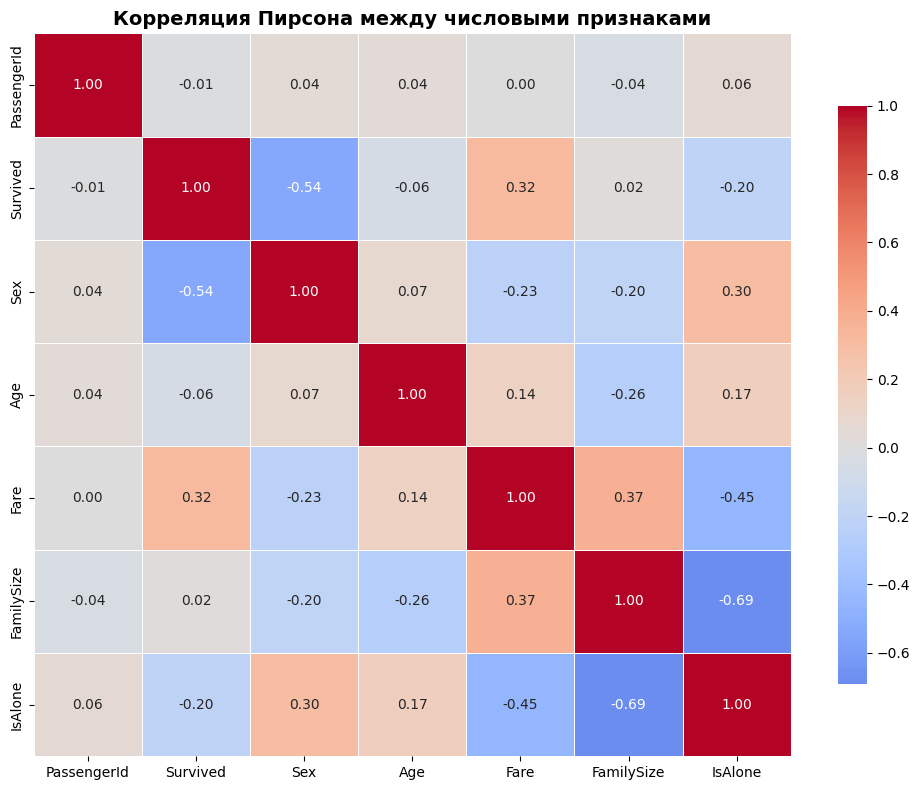

In [ ]:
numeric_cols = titanic_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

pearson_corr = titanic_df[numeric_cols].corr(method='pearson')

print("Матрица корреляций Пирсона:")
print(pearson_corr.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляция Пирсона между числовыми признаками', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()